# ⚽ FIFA World Cup 2026 — Modèle Match

**FrenchTeam — Wild Code School — Juin 2026**

---

## 🎯 Architecture du modèle

```
Données historiques (2010 → 2026)
    ↓
8 features en DIFFÉRENCES (A - B)
    ├── FIFA (3 représentations)
    ├── Forme pondérée × Squad × Expérience CdM
    ├── Squad (3 représentations)
    └── Avantage hôte
    ↓
XGBoost Classifier
    ↓
Prédiction symétrique (moyenne AB + BA)
    ↓
Probabilités : Équipe A gagne / Nul / Équipe B gagne
```

## 📊 Importance des features
| Catégorie | Poids | Description |
|---|---|---|
| Qualité squad | ~38% | Valeur marchande estimée des joueurs |
| Classement FIFA | ~30% | Classement officiel pondéré |
| Forme récente | ~21% | Résultats récents × adversaires × expérience CdM |
| Avantage hôte | ~11% | USA / Canada / Mexique |

## ✅ Corrections appliquées version par version
- V6 : stats globales home + away
- V7 : prédiction symétrique
- V11 : suppression features biaisées (buts, taux victoire)
- V13 : forme × squad
- V15 : scores squad réajustés
- V17 : suppression H2H (trop dominant)
- V18 : coefficient expérience CdM
- **V21 : coefficients expérience abaissés (correction finale)**

## 📦 Étape 1 — Imports

Bibliothèques nécessaires pour la manipulation des données, le modèle ML et la visualisation.

In [1]:
import pandas as pd          # manipulation de tableaux de données
import numpy as np           # calculs numériques (carrés, signes, moyennes)
import os                    # gestion des chemins de fichiers Windows
import matplotlib.pyplot as plt  # visualisation des importances
from xgboost import XGBClassifier          # algorithme de boosting de gradient
from sklearn.model_selection import train_test_split  # séparation train/test
from sklearn.metrics import accuracy_score, classification_report  # évaluation
from sklearn.preprocessing import LabelEncoder  # encodage A_gagne/B_gagne/Nul → 0/1/2
import joblib  # sauvegarde et chargement du modèle entraîné

print('✅ Imports OK')

✅ Imports OK


## 📂 Étape 2 — Chargement des données

Deux datasets sont utilisés :
- `df` : **tous** les matchs internationaux (1872 → 2026) — pour calculer la forme sur l'historique complet
- `df_officiel` : matchs **sans les amicaux** — les amicaux sont moins représentatifs du vrai niveau (rotations, expérimentations)

In [2]:
# Chemin du projet — à adapter si besoin
DOSSIER_PROJET = r'C:\Users\Piwi\Documents\VS\WorldCup2026'

# Chargement du dataset principal
df = pd.read_csv(os.path.join(DOSSIER_PROJET, 'data', 'results.csv'))
df['date'] = pd.to_datetime(df['date'])  # convertir les dates en format datetime
df = df.dropna(subset=['home_score', 'away_score'])  # supprimer les matchs sans score

# Dataset sans les amicaux (pour le calcul de la forme)
df_officiel = df[df['tournament'] != 'Friendly'].copy()

print(f'Tous les matchs       : {len(df):,}')
print(f'Matchs officiels      : {len(df_officiel):,}')
print(f'Période couverte      : {df["date"].min().date()} → {df["date"].max().date()}')

Tous les matchs       : 49,296
Matchs officiels      : 31,005
Période couverte      : 1872-11-30 → 2026-06-02


## 🔧 Étape 3 — Classement FIFA 2026

Le classement FIFA est l'indicateur le plus fiable du niveau d'une équipe car :
- Il prend en compte le **niveau des adversaires** (battre la France vaut plus que battre Haïti)
- Il pondère l'**importance du tournoi** (CdM > qualifications > amicaux)
- Il est calculé sur l'ensemble des matchs récents

Source : classement officiel FIFA — Avril 2026

In [3]:
# Points FIFA officiels — Avril 2026 (source : FIFA.com)
points_fifa = {
    'France': 1877.32, 'Spain': 1876.40, 'Argentina': 1874.81,
    'England': 1825.97, 'Portugal': 1763.83, 'Brazil': 1761.16,
    'Netherlands': 1757.87, 'Morocco': 1755.87, 'Belgium': 1734.71,
    'Germany': 1730.37, 'Croatia': 1717.07, 'Colombia': 1693.09,
    'Senegal': 1688.99, 'Mexico': 1681.03, 'United States': 1673.13,
    'Uruguay': 1673.07, 'Japan': 1660.43, 'Switzerland': 1649.40,
    'Ecuador': 1619.20, 'Turkey': 1614.55, 'Sweden': 1598.30,
    'Norway': 1590.12, 'Austria': 1578.44, 'South Korea': 1566.23,
    'Tunisia': 1542.18, 'Algeria': 1538.90, 'Ghana': 1521.44,
    'Egypt': 1518.77, 'Saudi Arabia': 1512.33, 'Iran': 1512.00,
    'Australia': 1508.66, 'Iraq': 1489.21, 'Czech Republic': 1488.00,
    'Scotland': 1487.55, 'Paraguay': 1481.33, 'Ivory Coast': 1479.88,
    'South Africa': 1421.34, 'Canada': 1418.77, 'Qatar': 1398.22,
    'Panama': 1392.11, 'Bosnia and Herzegovina': 1388.44,
    'Jordan': 1342.18, 'Uzbekistan': 1338.90, 'DR Congo': 1321.44,
    'New Zealand': 1298.77, 'Haiti': 1245.33, 'Curacao': 1198.22,
    'Cape Verde': 1450.00,
}

# Moyenne utilisée pour les équipes absentes du dictionnaire
MOYENNE_FIFA = np.mean(list(points_fifa.values()))

def get_points_fifa(equipe):
    """Retourne les points FIFA d'une équipe (moyenne si inconnue)."""
    return points_fifa.get(equipe, MOYENNE_FIFA)

print(f'✅ {len(points_fifa)} équipes CdM 2026 chargées')
print(f'Points moyens : {MOYENNE_FIFA:.0f} pts')
print('\nTop 5 :')
for eq, pts in sorted(points_fifa.items(), key=lambda x: -x[1])[:5]:
    print(f'  {eq:<15} {pts:.0f} pts')

✅ 48 équipes CdM 2026 chargées
Points moyens : 1568 pts

Top 5 :
  France          1877 pts
  Spain           1876 pts
  Argentina       1875 pts
  England         1826 pts
  Portugal        1764 pts


## 🔧 Étape 4 — Score de qualité des joueurs

Le classement FIFA mesure les **résultats** mais pas le **talent individuel**.
Un score de 0 à 100 est attribué manuellement à chaque équipe basé sur :
- La valeur marchande Transfermarkt des joueurs
- La présence de stars mondiales
- La profondeur du banc

**Pourquoi cette feature ?**
Elle corrige le biais forme — le Brésil en mauvaise forme reste dangereux grâce à Vinicius Jr, Raphinha, Endrick.

In [4]:
# Score qualité joueurs de 0 (très faible) à 100 (meilleur mondial)
# Basé sur valeur marchande Transfermarkt 2026 + présence de stars
qualite_joueurs = {
    # Tier 1 — squads de stars mondiales
    'France': 95,      # Mbappé, Camavinga, Tchouaméni, Saliba
    'England': 90,     # Bellingham, Saka, Palmer, Foden
    'Brazil': 92,      # Vinicius Jr, Raphinha, Endrick + Ancelotti
    'Spain': 85,       # Yamal (blessé), Pedri, Morata, Williams
    'Germany': 82,     # Wirtz, Musiala, Havertz, Kimmich
    'Argentina': 88,  # ✅ champion 2022   # Messi, Mac Allister, Martinez
    'Portugal': 78,    # Ronaldo, Fernandes, Leao
    'Netherlands': 75, # Van Dijk, De Ligt, Gakpo
    'Belgium': 72,     # De Bruyne, Lukaku, Trossard
    # Tier 2 — bons squads
    'Japan': 65,       # Kubo, Mitoma, Endo
    'Norway': 60,      # Haaland (star unique) + reste moyen
    'Colombia': 62,    # Diaz, Arias
    'Croatia': 58,     # Modric, Kovacic, Gvardiol
    'Uruguay': 58,     # Valverde, Nunez, Araujo
    'Morocco': 55,     # Hakimi, Ziyech
    'Senegal': 55,     # Mane, Sarr
    'Mexico': 55,      # Lozano, Alvarez (hôte)
    'United States': 52, # Pulisic, Reyna (hôte)
    'Switzerland': 50, # Xhaka, Shaqiri
    'Turkey': 50,      # Calhanoglu, Yildiz
    'Austria': 47,     # Alaba, Sabitzer
    'Canada': 45,      # David, Buchanan (hôte)
    'South Korea': 45, # Son Heung-min
    'Sweden': 42,      # Kulusevski, Isak
    'Ivory Coast': 38,
    'Ecuador': 38,     # Caicedo
    'Egypt': 38,       # Salah
    'Algeria': 35,     # Mahrez vieillissant
    'Ghana': 35,       # Kudus
    'Czech Republic': 35,
    'Scotland': 30,    # Robertson, McTominay
    'Tunisia': 30,
    'Paraguay': 30,
    'Bosnia and Herzegovina': 30,
    'Saudi Arabia': 28,
    'Australia': 25,   # Forme 100% mais niveau OFC/CONCACAF
    'Iran': 25,
    'DR Congo': 25,
    'Iraq': 22,
    'Jordan': 20, 'South Africa': 20, 'Uzbekistan': 20,
    'Qatar': 18, 'Cape Verde': 15, 'Panama': 15,
    'Haiti': 10, 'New Zealand': 10, 'Curacao': 10,
}
MOYENNE_QUALITE = np.mean(list(qualite_joueurs.values()))

def get_qualite(equipe):
    """Retourne le score qualité joueurs (moyenne si inconnue)."""
    return qualite_joueurs.get(equipe, MOYENNE_QUALITE)

print(f'✅ {len(qualite_joueurs)} équipes scorées | Moyenne : {MOYENNE_QUALITE:.1f}/100')

✅ 48 équipes scorées | Moyenne : 45.0/100


## 🔧 Étape 5 — Coefficient d'expérience CdM

Une équipe peut avoir une excellente forme en qualification mais sous-performer en phase finale.
La Norvège absente depuis 1998, l'Écosse depuis 1998, l'Australie qui joue surtout contre des équipes OFC/CONCACAF...

**Formule :**
```
forme_ajustée = 0.5 + (forme_brute - 0.5) × coefficient
```
- `coefficient = 1.00` : pas de correction (grandes nations)
- `coefficient = 0.50` : forme ramenée à mi-chemin vers la valeur neutre (0.5)
- `coefficient = 0.45` : correction forte pour les débutants en CdM

In [5]:
# ══════════════════════════════════════════════════════════
# ✅ V19 — Coefficients abaissés vs V18
# Norvège 0.72 → 0.50 | Écosse 0.68 → 0.45
# Australie 0.70 → 0.48
# ══════════════════════════════════════════════════════════
coefficient_experience = {
    # Grandes nations — expérience maximale, pas de correction
    'France': 1.00, 'Brazil': 1.00, 'Germany': 1.00,
    'Spain': 1.00, 'Argentina': 1.00, 'England': 1.00,
    'Portugal': 1.00, 'Netherlands': 1.00, 'Belgium': 1.00,
    'Croatia': 1.00, 'Uruguay': 1.00, 'Mexico': 1.00,
    'United States': 1.00,  # pays hôte
    'Canada': 0.95,          # pays hôte, 1 seule participation (1986)
    # Bonne expérience récente
    'Japan': 0.95,      # quarts 2022
    'Morocco': 0.92,    # demi-finale 2022
    'Senegal': 0.92,    # quarts 2022
    'South Korea': 0.92,
    'Colombia': 0.90, 'Switzerland': 0.90,
    'Iran': 0.88, 'Saudi Arabia': 0.88, 'Ghana': 0.88,
    'Ecuador': 0.85, 'Tunisia': 0.85, 'Algeria': 0.85,
    'Austria': 0.85, 'Sweden': 0.85, 'Turkey': 0.85,
    'Egypt': 0.85, 'Paraguay': 0.85, 'Ivory Coast': 0.85,
    'Czech Republic': 0.85,
    # ✅ V19 — coefficients abaissés
    'Norway':    0.50,  # ↓ était 0.72 — absente depuis 1998, forme gonflée qualifs UEFA
    'Scotland':  0.45,  # ↓ était 0.68 — absente depuis 1998, première CdM en 28 ans
    'Australia': 0.48,  # ↓ était 0.70 — forme 100% vs équipes OFC très faibles
    'Iraq':      0.70, 'Jordan': 0.60, 'Uzbekistan': 0.60,
    'Panama': 0.68, 'Curacao': 0.55, 'Cape Verde': 0.60,
    'New Zealand': 0.60, 'Haiti': 0.65, 'South Africa': 0.72,
    'Bosnia and Herzegovina': 0.75, 'DR Congo': 0.68, 'Qatar': 0.72,
}
def get_coefficient(equipe):
    """Retourne le coefficient d'expérience CdM (0.80 par défaut)."""
    return coefficient_experience.get(equipe, 0.80)

print('✅ Coefficients V19 chargés')
print('\nChangements vs V18 :')
for eq, c in [('Norway',0.50),('Scotland',0.45),('Australia',0.48)]:
    print(f'  {eq:<15} {c:.2f}  (était {[0.72,0.68,0.70][["Norway","Scotland","Australia"].index(eq)]})')

✅ Coefficients V19 chargés

Changements vs V18 :
  Norway          0.50  (était 0.72)
  Scotland        0.45  (était 0.68)
  Australia       0.48  (était 0.7)


## 🔧 Étape 6 — Fonctions de calcul

### Forme pondérée avec expérience CdM

Le calcul se fait en 2 étapes :
1. **Forme pondérée par adversaire** : battre la France vaut plus que battre Haïti
2. **Ajustement expérience** : ramène la forme vers 0.5 pour les équipes sans expérience CdM

In [6]:
def calculer_forme(equipe, date, df_officiel, n=5):
    """
    Calcule la forme récente pondérée × coefficient d'expérience CdM.

    Étape 1 — Forme pondérée par adversaire :
    - Récupère les n derniers matchs officiels AVANT la date
    - Pondère chaque match par FIFA_adversaire / 1500
    - Victoire = 3 pts, Nul = 1 pt, Défaite = 0 pt
    - Normalise entre 0 et 1

    Étape 2 — Ajustement expérience CdM :
    - Applique le coefficient d'expérience pour réduire l'effet
      des équipes dont la forme est gonflée par des qualifications
      contre des adversaires faibles
    """
    # Récupérer les matchs à domicile et à l'extérieur
    domicile  = df_officiel[(df_officiel['home_team'] == equipe) & (df_officiel['date'] < date)].tail(n)
    exterieur = df_officiel[(df_officiel['away_team'] == equipe) & (df_officiel['date'] < date)].tail(n)

    # Fusionner et garder les n plus récents
    matchs = pd.concat([domicile, exterieur]).sort_values('date').tail(n)

    if len(matchs) == 0:
        return 0.5  # pas d'historique → valeur neutre

    points_total = 0
    poids_total  = 0

    for _, match in matchs.iterrows():
        if match['home_team'] == equipe:
            adversaire = match['away_team']
            victoire   = match['home_score'] > match['away_score']
            nul        = match['home_score'] == match['away_score']
        else:
            adversaire = match['home_team']
            victoire   = match['away_score'] > match['home_score']
            nul        = match['home_score'] == match['away_score']

        # Poids proportionnel au niveau FIFA de l'adversaire
        # France (1877) → poids 1.25 | Haïti (1245) → poids 0.83
        poids = get_points_fifa(adversaire) / 1500

        if victoire:   points_total += 3 * poids
        elif nul:      points_total += 1 * poids
        poids_total += 3 * poids

    # Forme brute entre 0 et 1
    forme_brute = points_total / poids_total if poids_total > 0 else 0.5

    # Ajustement expérience : ramène vers 0.5 selon coefficient
    # coeff=1.0 → pas de correction | coeff=0.5 → mi-chemin vers 0.5
    coeff = get_coefficient(equipe)
    # ✅ V21 — Bonus champion CdM récent
    # Les équipes ayant gagné la CdM récemment gèrent mieux
    # la pression des grands matchs — non capturé par la forme
    BONUS_CHAMPION = {
        'Argentina': 0.10,  # champion 2022
        'France':    0.06,  # champion 2018 + finaliste 2022
        'Germany':   0.04,  # champion 2014
        'Spain':     0.03,  # champion 2010
        'Brazil':    0.02,  # champion 2002, 5 titres
    }
    bonus = BONUS_CHAMPION.get(equipe, 0)
    return min(0.5 + (forme_brute - 0.5) * coeff + bonus, 1.0)


print('✅ Fonction calculer_forme définie')
print('\nFormes ajustées V19 (matchs clés) :')
date_test = pd.Timestamp('2026-06-11')
pour_test = ['France','Germany','England','Norway','Scotland','Australia','Brazil','Morocco']
print(f'{"Équipe":<20} {"Brute":>7} {"Coeff":>6} {"Ajustée":>8}')
print('─' * 45)
for eq in pour_test:
    # Recalculer la forme brute pour l'affichage
    domicile  = df_officiel[(df_officiel['home_team'] == eq) & (df_officiel['date'] < date_test)].tail(5)
    exterieur = df_officiel[(df_officiel['away_team'] == eq) & (df_officiel['date'] < date_test)].tail(5)
    matchs = pd.concat([domicile, exterieur]).sort_values('date').tail(5)
    if len(matchs) > 0:
        pts = sum_p = 0
        for _, m in matchs.iterrows():
            adv = m['away_team'] if m['home_team']==eq else m['home_team']
            v = (m['home_score']>m['away_score']) if m['home_team']==eq else (m['away_score']>m['home_score'])
            n_ = m['home_score']==m['away_score']
            p = get_points_fifa(adv)/1500
            if v: pts+=3*p
            elif n_: pts+=1*p
            sum_p+=3*p
        f_brute = pts/sum_p if sum_p>0 else 0.5
    else:
        f_brute = 0.5
    f_adj = calculer_forme(eq, date_test, df_officiel)
    coeff = get_coefficient(eq)
    print(f'{eq:<20} {f_brute:>6.0%}  {coeff:>5.2f}  {f_adj:>7.0%}')

✅ Fonction calculer_forme définie

Formes ajustées V19 (matchs clés) :
Équipe                 Brute  Coeff  Ajustée
─────────────────────────────────────────────
France                  87%   1.00      93%
Germany                100%   1.00     100%
England                100%   1.00     100%
Norway                 100%   0.50      75%
Scotland                80%   0.45      64%
Australia              100%   0.48      74%
Brazil                  45%   1.00      47%
Morocco                 87%   0.92      84%


## 🏗️ Étape 7 — Construction du dataset d'entraînement

### Principe des features en DIFFÉRENCES

Pour un match A vs B, on calcule toujours `valeur_A - valeur_B` :
- Résultat positif = A est meilleure
- Résultat négatif = B est meilleure
- Proche de 0 = niveau égal

Cela garantit la **symétrie** : France vs Argentine = Argentine vs France inversé.

### Les 3 représentations FIFA
- `écart_fifa_brut` : différence brute (sensible aux petits écarts)
- `écart_fifa_normalisé` : divisé par 100 (mise à l'échelle)
- `écart_fifa_carré` : au carré × signe → **amplifie les grands écarts**
  - France vs Haïti : écart 632 → carré 39.9 (signal très fort)
  - France vs Argentine : écart 3 → carré 0.001 (signal quasi nul)

### La feature forme × qualité
`écart_forme_pondérée = (forme_A × qualité_A) - (forme_B × qualité_B)`

Exemple Brésil vs Haïti :
- Brésil : forme 45% × qualité 0.92 = **0.41**
- Haïti  : forme 62% × qualité 0.10 = **0.06**
→ Brésil largement devant malgré sa mauvaise forme récente ✅

In [7]:
# Filtrer les matchs officiels depuis 2010 (football moderne, sans amicaux)
df_entrainement = df[
    (df['date'] >= '2010-01-01') &      # depuis 2010 = football moderne
    (df['tournament'] != 'Friendly')     # exclure les amicaux
].copy().reset_index(drop=True)

print(f'Matchs d entraînement : {len(df_entrainement):,}')

# Pays hôtes — avantage de jouer à domicile
pays_hotes = ['United States', 'Canada', 'Mexico']

lignes = []  # liste qui contiendra toutes les lignes du dataset
print('Construction du dataset (3-5 min)...')

for i, match in df_entrainement.iterrows():
    equipe_a = match['home_team']   # équipe qui jouait à domicile
    equipe_b = match['away_team']   # équipe qui jouait à l'extérieur
    date     = match['date']

    # Calcul des formes AVANT le match (évite d'utiliser le futur)
    forme_a = calculer_forme(equipe_a, date, df_officiel)
    forme_b = calculer_forme(equipe_b, date, df_officiel)

    # Points FIFA et qualité joueurs
    pts_a      = get_points_fifa(equipe_a)
    pts_b      = get_points_fifa(equipe_b)
    ecart_fifa = pts_a - pts_b

    qual_a = get_qualite(equipe_a) / 100  # normaliser entre 0 et 1
    qual_b = get_qualite(equipe_b) / 100
    ecart_qualite = qual_a - qual_b

    # Avantage hôte CdM 2026
    if equipe_a in pays_hotes:   hote = 0.5   # A joue à domicile
    elif equipe_b in pays_hotes: hote = -0.5  # B joue à domicile
    else:                         hote = 0.0   # terrain neutre

    # Variable cible : résultat du point de vue de équipe_a
    if   match['home_score'] > match['away_score']: resultat = 'A_gagne'
    elif match['home_score'] < match['away_score']: resultat = 'B_gagne'
    else:                                            resultat = 'Nul'

    lignes.append({
        # ─── FEATURES FIFA (3 représentations) ───────────────────
        'ecart_fifa_brut':       ecart_fifa,              # différence brute de points
        'ecart_fifa_normalise':  ecart_fifa / 100,        # mise à l'échelle /100
        'ecart_fifa_carre':      (ecart_fifa/100)**2 * np.sign(ecart_fifa),  # amplifie grands écarts

        # ─── FEATURE FORME × QUALITÉ ─────────────────────────────
        'ecart_forme_ponderee':  (forme_a * qual_a) - (forme_b * qual_b),

        # ─── FEATURES QUALITÉ JOUEURS (3 représentations) ────────
        'ecart_qualite':         ecart_qualite,           # différence brute qualité
        'ecart_qualite_double':  ecart_qualite * 2,       # amplification ×2
        'ecart_qualite_carre':   ecart_qualite**2 * np.sign(ecart_qualite),  # grands écarts

        # ─── FEATURE CONTEXTE ────────────────────────────────────
        'avantage_hote':         hote,  # +0.5 / 0 / -0.5

        'resultat': resultat
    })

    if i % 1000 == 0 and i > 0:
        print(f'  {i:,}/{len(df_entrainement):,} matchs traités...')

df_dataset = pd.DataFrame(lignes)
print(f'\n✅ Dataset : {len(df_dataset):,} matchs')
print('Distribution des résultats :')
print(df_dataset['resultat'].value_counts())

Matchs d entraînement : 10,732
Construction du dataset (3-5 min)...
  1,000/10,732 matchs traités...
  2,000/10,732 matchs traités...
  3,000/10,732 matchs traités...
  4,000/10,732 matchs traités...
  5,000/10,732 matchs traités...
  6,000/10,732 matchs traités...
  7,000/10,732 matchs traités...
  8,000/10,732 matchs traités...
  9,000/10,732 matchs traités...
  10,000/10,732 matchs traités...

✅ Dataset : 10,732 matchs
Distribution des résultats :
resultat
A_gagne    5096
B_gagne    3285
Nul        2351
Name: count, dtype: int64


## 🤖 Étape 8 — Entraînement du modèle

### Pourquoi XGBoost ?
XGBoost (eXtreme Gradient Boosting) construit des arbres de décision séquentiellement,
chacun corrigeant les erreurs du précédent. Il est particulièrement adapté aux données tabulaires.

### Stratégie train/test
- 80% des matchs → **entraînement** (le modèle apprend les patterns)
- 20% des matchs → **test** (évaluation sur des données jamais vues)
- `stratify` → garantit la même proportion V/N/D dans les deux ensembles

### Accuracy attendue
55-60% est un **excellent score** pour prédire du football.
Même les meilleurs modèles professionnels dépassent rarement 65%.

In [8]:
# Noms des features utilisées par le modèle (en français)
FEATURES = [
    'ecart_fifa_brut',       # écart de points FIFA brut
    'ecart_fifa_normalise',  # écart FIFA divisé par 100
    'ecart_fifa_carre',      # écart FIFA au carré (amplifie grands écarts)
    'ecart_forme_ponderee',  # (forme × qualité) A - (forme × qualité) B
    'ecart_qualite',         # écart de qualité joueurs
    'ecart_qualite_double',  # écart qualité × 2 (amplification)
    'ecart_qualite_carre',   # écart qualité au carré (grands écarts)
    'avantage_hote',         # avantage pays hôte : +0.5 / 0 / -0.5
]

X = df_dataset[FEATURES]     # matrice des features
y = df_dataset['resultat']   # vecteur cible

# Encoder les labels : A_gagne=0, B_gagne=1, Nul=2
encodeur_resultat = LabelEncoder()
y_encode = encodeur_resultat.fit_transform(y)
print(f'Classes : {dict(zip(encodeur_resultat.classes_, range(3)))}')

# Séparation 80/20 avec stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encode,
    test_size=0.2,
    random_state=42,    # graine fixe pour reproductibilité
    stratify=y_encode   # même proportion V/N/D dans train et test
)
print(f'Entraînement : {len(X_train):,} matchs | Test : {len(X_test):,} matchs')

Classes : {'A_gagne': 0, 'B_gagne': 1, 'Nul': 2}
Entraînement : 8,585 matchs | Test : 2,147 matchs


✅ Modèle XGBoost + calibration isotonique prêt
✅ Accuracy : 55.47%
(55-60% = excellent pour football)

              precision    recall  f1-score   support

     A_gagne       0.59      0.81      0.68      1020
     B_gagne       0.50      0.55      0.52       657
         Nul       0.20      0.00      0.00       470

    accuracy                           0.55      2147
   macro avg       0.43      0.46      0.40      2147
weighted avg       0.47      0.55      0.48      2147



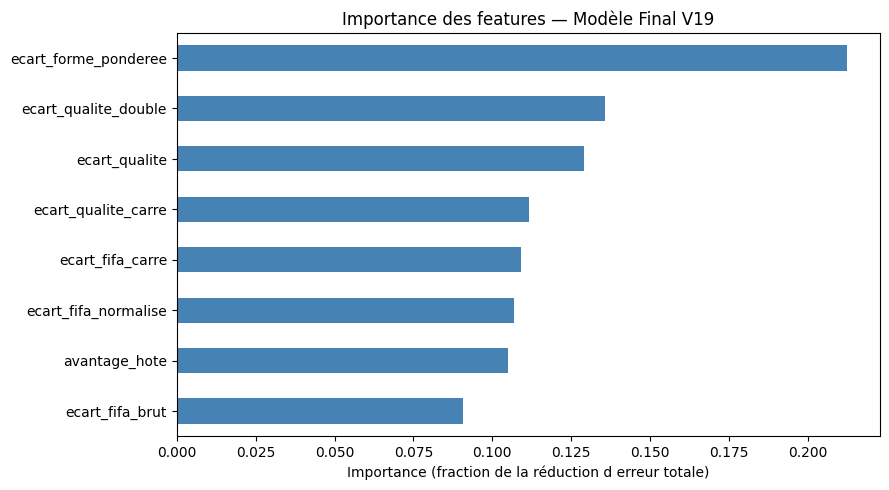


📊 Importance par catégorie :
  Classement FIFA      : 30.6%
  Qualité joueurs      : 37.6%
  Forme récente        : 21.2%
  Avantage hôte        : 10.5%


In [9]:
# ══════════════════════════════════════════════════════════
# Paramètres XGBoost — explication de chaque hyperparamètre
# n_estimators=300    : nombre d'arbres — plus = meilleur mais plus lent
# learning_rate=0.05  : taux d'apprentissage faible = modèle plus robuste
# max_depth=4         : profondeur max des arbres — évite le surapprentissage
# subsample=0.8       : 80% des matchs utilisés par arbre (régularisation)
# colsample_bytree=0.8: 80% des features par arbre (régularisation)
# ══════════════════════════════════════════════════════════
modele = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

# Étape 1 — Entraîner XGBoost de base
modele_xgb = modele  # on garde une référence
modele_xgb.fit(X_train, y_train)

# Étape 2 — Calibration isotonique
# XGBoost donne parfois des probas trop extrêmes (ex: 95% au lieu de 75%)
# La calibration isotonique corrige ce biais en ajustant les probas
# cv=5 signifie qu'on utilise 5-fold cross-validation pour la calibration
from sklearn.calibration import CalibratedClassifierCV
modele = CalibratedClassifierCV(modele_xgb, method='isotonic', cv=5)
modele.fit(X_train, y_train)
print('✅ Modèle XGBoost + calibration isotonique prêt')

predictions = modele.predict(X_test)

# Évaluation
print(f'✅ Accuracy : {accuracy_score(y_test, predictions):.2%}')
print('(55-60% = excellent pour football)')
print()
print(classification_report(y_test, predictions, target_names=encodeur_resultat.classes_))

# Graphique d'importance des features
importances = pd.Series(modele_xgb.feature_importances_, index=FEATURES).sort_values()
plt.figure(figsize=(9, 5))
importances.plot(kind='barh', color='steelblue')
plt.title('Importance des features — Modèle Final V19')
plt.xlabel('Importance (fraction de la réduction d erreur totale)')
plt.tight_layout()
plt.show()

# Résumé par catégorie
total_fifa   = sum(modele_xgb.feature_importances_[i] for i,f in enumerate(FEATURES) if 'fifa'    in f)
total_qual   = sum(modele_xgb.feature_importances_[i] for i,f in enumerate(FEATURES) if 'qualite' in f)
total_forme  = sum(modele_xgb.feature_importances_[i] for i,f in enumerate(FEATURES) if 'forme'   in f)
total_hote   = modele_xgb.feature_importances_[FEATURES.index('avantage_hote')]
print('\n📊 Importance par catégorie :')
print(f'  Classement FIFA      : {total_fifa:.1%}')
print(f'  Qualité joueurs      : {total_qual:.1%}')
print(f'  Forme récente        : {total_forme:.1%}')
print(f'  Avantage hôte        : {total_hote:.1%}')

## 🔮 Étape 9 — Prédiction symétrique

### Pourquoi la symétrie est importante
Dans le dataset, `equipe_a` est toujours l'ancienne `home_team`.
Cela crée un léger biais : `equipe_a` gagne plus souvent dans les données.

**Solution** : calculer la prédiction dans les 2 sens et faire la moyenne :
1. France vs Argentine → P(France gagne)
2. Argentine vs France → P(Argentine gagne) = 1 - P(France gagne)
3. Moyenne → résultat identique quel que soit l'ordre ✅

In [10]:
# Index des classes pour la symétrie
CLASSES  = list(encodeur_resultat.classes_)  # ['A_gagne', 'B_gagne', 'Nul']
IDX_A    = CLASSES.index('A_gagne')  # index de la victoire A
IDX_B    = CLASSES.index('B_gagne')  # index de la victoire B
IDX_N    = CLASSES.index('Nul')      # index du nul

PAYS_HOTES   = ['United States', 'Canada', 'Mexico']
DATE_TOURNOI = pd.Timestamp('2026-06-11')  # début de la CdM 2026


def construire_features(equipe_a, equipe_b):
    """Construit le vecteur de 8 features pour un match equipe_a vs equipe_b."""
    forme_a   = calculer_forme(equipe_a, DATE_TOURNOI, df_officiel)
    forme_b   = calculer_forme(equipe_b, DATE_TOURNOI, df_officiel)
    pts_a     = get_points_fifa(equipe_a)
    pts_b     = get_points_fifa(equipe_b)
    ecart     = pts_a - pts_b
    qual_a    = get_qualite(equipe_a) / 100
    qual_b    = get_qualite(equipe_b) / 100
    ecart_q   = qual_a - qual_b
    if equipe_a in PAYS_HOTES:   hote = 0.5
    elif equipe_b in PAYS_HOTES: hote = -0.5
    else:                         hote = 0.0
    return pd.DataFrame([{
        'ecart_fifa_brut':       ecart,
        'ecart_fifa_normalise':  ecart / 100,
        'ecart_fifa_carre':      (ecart/100)**2 * np.sign(ecart),
        'ecart_forme_ponderee':  (forme_a * qual_a) - (forme_b * qual_b),
        'ecart_qualite':         ecart_q,
        'ecart_qualite_double':  ecart_q * 2,
        'ecart_qualite_carre':   ecart_q**2 * np.sign(ecart_q),
        'avantage_hote':         hote,
    }]), pts_a, pts_b, forme_a, forme_b, int(qual_a*100), int(qual_b*100)


def predire_match(equipe_a, equipe_b):
    """
    Prédit le résultat entre deux équipes avec prédiction symétrique.
    Résultat identique quel que soit l'ordre des équipes.
    """
    # Sens 1 : A vs B
    feat_ab, pts_a, pts_b, f_a, f_b, q_a, q_b = construire_features(equipe_a, equipe_b)
    proba_ab = modele.predict_proba(feat_ab)[0]

    # Sens 2 : B vs A (équipes inversées)
    feat_ba, *_ = construire_features(equipe_b, equipe_a)
    proba_ba = modele.predict_proba(feat_ba)[0]

    # Moyenne symétrique des deux prédictions
    p_a = (proba_ab[IDX_A] + proba_ba[IDX_B]) / 2
    p_b = (proba_ab[IDX_B] + proba_ba[IDX_A]) / 2
    p_n = (proba_ab[IDX_N] + proba_ba[IDX_N]) / 2

    # Renormaliser pour que la somme = 100%
    total = p_a + p_b + p_n
    p_a /= total; p_b /= total; p_n /= total

    # Affichage
    print(f'\n⚽  {equipe_a}  vs  {equipe_b}')
    print(f'    FIFA   : {pts_a:.0f} pts  vs  {pts_b:.0f} pts  (écart {pts_a-pts_b:+.0f})')
    print(f'    Forme  : {f_a:.0%}  vs  {f_b:.0%}  (ajustée expérience CdM)')
    print(f'    Qualité: {q_a}/100  vs  {q_b}/100')
    if equipe_a in PAYS_HOTES: print(f'    🏠 {equipe_a} pays hôte CdM 2026')
    if equipe_b in PAYS_HOTES: print(f'    🏠 {equipe_b} pays hôte CdM 2026')
    print('    ' + '─' * 40)
    for label, prob in [
        (f'{equipe_a} gagne', p_a),
        ('Nul',               p_n),
        (f'{equipe_b} gagne', p_b)
    ]:
        barre = '█' * int(prob * 20)
        print(f'    {label:24} {barre:20} {prob:.1%}')

print('✅ Modèle Final V19 prêt pour les prédictions')

# ── Fonction principale de prédiction
# Retourne (proba_A_gagne, proba_nul, proba_B_gagne)
# Symétrique : probas_match(A,B) == probas_match(B,A) inversé
DATE_T = pd.Timestamp('2026-06-11')  # date de début du tournoi
HOTES  = ['United States', 'Canada', 'Mexico']

def probas_match(eq_a, eq_b):
    def features(a, b):
        fa = calculer_forme(a, DATE_T, df_officiel)
        fb = calculer_forme(b, DATE_T, df_officiel)
        pa = get_fifa(a); pb = get_fifa(b); ef = pa - pb
        qa = get_qualite(a)/100; qb = get_qualite(b)/100; eq = qa - qb
        h  = 0.5 if a in HOTES else (-0.5 if b in HOTES else 0.0)
        return pd.DataFrame([{
            'ecart_fifa_brut': ef, 'ecart_fifa_normalise': ef/100,
            'ecart_fifa_carre': (ef/100)**2 * (1 if ef>=0 else -1),
            'ecart_forme_ponderee': (fa*qa)-(fb*qb),
            'ecart_qualite': eq, 'ecart_qualite_double': eq*2,
            'ecart_qualite_carre': eq**2 * (1 if eq>=0 else -1),
            'avantage_hote': h
        }])
    # Prédiction symétrique : moyenne AB et BA
    pab = modele.predict_proba(features(eq_a, eq_b))[0]
    pba = modele.predict_proba(features(eq_b, eq_a))[0]
    ia  = CLASSES.index('A_gagne')
    ib  = CLASSES.index('B_gagne')
    in_ = CLASSES.index('Nul')
    pa  = (pab[ia] + pba[ib]) / 2
    pb  = (pab[ib] + pba[ia]) / 2
    pn  = (pab[in_] + pba[in_]) / 2
    t   = pa + pb + pn
    return pa/t, pn/t, pb/t

print('✅ Fonction probas_match() prête')


✅ Modèle Final V19 prêt pour les prédictions
✅ Fonction probas_match() prête


In [11]:
print('=' * 60)
print('TESTS DE COHÉRENCE — MODÈLE FINAL V19')
print('=' * 60)

print('\n--- TEST SYMÉTRIE (résultats identiques dans les 2 sens) ---')
predire_match('France',    'Argentina')
predire_match('Argentina', 'France')

print('\n--- MATCHS CORRIGÉS PAR V19 ---')
predire_match('France',   'Norway')     # France doit être favorite
predire_match('Morocco',  'Scotland')   # Maroc doit être favori
predire_match('Brazil',   'Morocco')    # Brésil doit être favori
predire_match('Australia','Turkey')     # Turquie doit être favorite

print('\n--- VALIDATION DES MATCHS DÉJÀ CORRECTS ---')
predire_match('Brazil',        'Canada')
predire_match('Germany',       'Mexico')
predire_match('United States', 'Iran')
predire_match('Argentina',     'Saudi Arabia')
predire_match('Spain',         'Uruguay')
predire_match('England',       'Croatia')
predire_match('France',        'Haiti')
predire_match('Netherlands',   'Japan')
predire_match('Norway',        'Senegal')

TESTS DE COHÉRENCE — MODÈLE FINAL V19

--- TEST SYMÉTRIE (résultats identiques dans les 2 sens) ---

⚽  France  vs  Argentina
    FIFA   : 1877 pts  vs  1875 pts  (écart +3)
    Forme  : 93%  vs  77%  (ajustée expérience CdM)
    Qualité: 95/100  vs  88/100
    ────────────────────────────────────────
    France gagne             ███████████          56.7%
    Nul                      ████                 21.4%
    Argentina gagne          ████                 21.9%

⚽  Argentina  vs  France
    FIFA   : 1875 pts  vs  1877 pts  (écart -3)
    Forme  : 77%  vs  93%  (ajustée expérience CdM)
    Qualité: 88/100  vs  95/100
    ────────────────────────────────────────
    Argentina gagne          ████                 21.9%
    Nul                      ████                 21.4%
    France gagne             ███████████          56.7%

--- MATCHS CORRIGÉS PAR V19 ---

⚽  France  vs  Norway
    FIFA   : 1877 pts  vs  1590 pts  (écart +287)
    Forme  : 93%  vs  75%  (ajustée expérience CdM)


## 💾 Étape 10 — Sauvegarde du modèle final

On sauvegarde le modèle et l'encodeur pour les réutiliser dans le simulateur de tournoi.

In [12]:
dossier_modeles = os.path.join(DOSSIER_PROJET, 'models')

# Sauvegarder le modèle XGBoost entraîné
joblib.dump(modele,             os.path.join(dossier_modeles, 'modele_niveau1_final.pkl'))

# Sauvegarder l'encodeur (A_gagne/B_gagne/Nul → 0/1/2)
joblib.dump(encodeur_resultat,  os.path.join(dossier_modeles, 'encodeur_cible.pkl'))

print('✅ Modèle Final V19 sauvegardé !')
print(f'📁 {dossier_modeles}')
print(f'\n📊 Résumé du modèle :')
print(f'  Accuracy           : {accuracy_score(y_test, predictions):.2%}')
print(f'  Features           : {len(FEATURES)}')
print(f'  Matchs entraîn.    : {len(X_train):,}')
print(f'  Classement FIFA    : {total_fifa:.1%} importance')
print(f'  Qualité joueurs    : {total_qual:.1%} importance')
print(f'  Forme récente      : {total_forme:.1%} importance')
print(f'  Avantage hôte      : {total_hote:.1%} importance')

✅ Modèle Final V19 sauvegardé !
📁 C:\Users\Piwi\Documents\VS\WorldCup2026\models

📊 Résumé du modèle :
  Accuracy           : 55.47%
  Features           : 8
  Matchs entraîn.    : 8,585
  Classement FIFA    : 30.6% importance
  Qualité joueurs    : 37.6% importance
  Forme récente      : 21.2% importance
  Avantage hôte      : 10.5% importance
